# CNN on CIFAR-10 — fixed, runnable version (with shape comments & visualizations)

This notebook is a debugged, runnable version of the original hand-rolled CNN code.

**Bugs fixed from the original code:**

1. `BatchNorm` / `Dropout` / `Pooling`: `nn.Parameter` / attributes were assigned **before** `super().__init__()` — PyTorch requires `super().__init__()` first. Also `BatchNorm` never applied `gamma`/`beta`; now it returns `gamma * x_norm + beta`.
2. Rewritten as standard *inverted dropout* (scale by `1/(1-p)` at train time, identity at eval time).
3. `Dense.forward`: `torch.matmul(self.W, x)` had the operands in the wrong order for `W` of shape `(in_dim, out_dim)` → changed to `x @ W + b`; also `self.function` was never stored.
4. Training used only the **first batch** of the dataset (`next(iter(loader))`) for all epochs → replaced with a proper mini-batch training loop over the full dataset (`shuffle=True` for training).
5. `zca_whitening`: eigenvalues of a rank-deficient covariance matrix can be ≤ 0 → `pow(-0.5)` produced `inf`/`nan`. Added an epsilon: `(λ + ε)^(-1/2)`.


In [1]:
# ================= Imports & configuration =================
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.metrics import accuracy_score, f1_score

rng = np.random.RandomState(1234)   # numpy RNG for weight init (reproducible)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

batch_size = 64


Device: cuda


## 1. Preprocessing: GCN and ZCA whitening

* **GCN (Global Contrast Normalization)** — per-image standardization: `(x - mean) / std`.
* **ZCA whitening** — decorrelates pixels across a *set* of images using the eigendecomposition of the pixel covariance matrix. Needs many images (we use 1,000) because the covariance matrix is `3072 × 3072`.

In [3]:
def gcn(img):
    """Global Contrast Normalization.

    Args:
        img: (C, H, W) = (3, 32, 32)
    Returns:
        (C, H, W) tensor, zero mean / unit std over all 3072 values.
    """
    flattened_img = torch.flatten(img)          # (C,H,W) -> (3072,)
    std_img  = torch.std(flattened_img)         # scalar
    mean_img = torch.mean(flattened_img)        # scalar
    epsilon = 1e-5
    return (img - mean_img) / (std_img + epsilon)   # broadcast -> (3, 32, 32)


def deprocess(img):
    """Min-max scale an image back into [0, 1] for display.

    Args: img: (C, H, W)  ->  Returns: (C, H, W) in [0, 1]
    """
    flattened_img = torch.flatten(img)          # (3072,)
    max_img = torch.max(flattened_img)          # scalar
    min_img = torch.min(flattened_img)          # scalar
    return (img - min_img) / (max_img - min_img + 1e-12)


def zca_whitening(images, eps=1e-2):
    """ZCA whitening of a batch of images.

    Args:
        images: (N, C, H, W) = (N, 3, 32, 32)
    Returns:
        images_whitened: (N, C, H, W)
        ZCA_matrix:      (C*H*W, C*H*W) = (3072, 3072) — reusable for new images
        mean_vec:        (1, 3072)
    """
    N, C, H, W = images.shape
    images_flat = images.reshape(N, -1)                     # (N, 3072)

    # ---- Step 1: mean over the batch ----
    mean_vec = images_flat.mean(dim=0, keepdim=True)        # (1, 3072)

    # ---- Step 2: center ----
    images_centered = images_flat - mean_vec                # (N, 3072) - (1, 3072) -> (N, 3072)

    # ---- Step 3: covariance matrix ----
    # (3072, N) @ (N, 3072) = (3072, 3072)
    cov_matrix = torch.mm(images_centered.T, images_centered) / (N - 1)

    # ---- Step 4: eigendecomposition  cov = V diag(lam) V^T ----
    eigenvalues, eigenvectors = torch.linalg.eigh(cov_matrix)
    # eigenvalues: (3072,), eigenvectors: (3072, 3072)

    # ---- Step 5: ZCA matrix = V diag(1/sqrt(lam + eps)) V^T ----
    # eps guards against lam <= 0 (covariance is rank-deficient when N < 3072!)
    sqrt_inv_evals = (eigenvalues + eps).pow(-0.5)          # (3072,)
    diag_matrix = torch.diag(sqrt_inv_evals)                # (3072, 3072)
    ZCA_matrix = eigenvectors @ diag_matrix @ eigenvectors.T  # (3072, 3072)

    # ---- Step 6: apply ----
    images_whitened_flat = images_centered @ ZCA_matrix.T   # (N, 3072)
    images_whitened = images_whitened_flat.reshape(N, C, H, W)  # (N, 3, 32, 32)

    print(f'flat {images_flat.shape} | mean {mean_vec.shape} | cov {cov_matrix.shape} '
          f'| ZCA {ZCA_matrix.shape} | out {images_whitened.shape}')
    return images_whitened, ZCA_matrix, mean_vec


100%|██████████| 170M/170M [1:21:01<00:00, 35.1kB/s]


demo batch: torch.Size([1000, 3, 32, 32])
flat torch.Size([1000, 3072]) | mean torch.Size([1, 3072]) | cov torch.Size([3072, 3072]) | ZCA torch.Size([3072, 3072]) | out torch.Size([1000, 3, 32, 32])


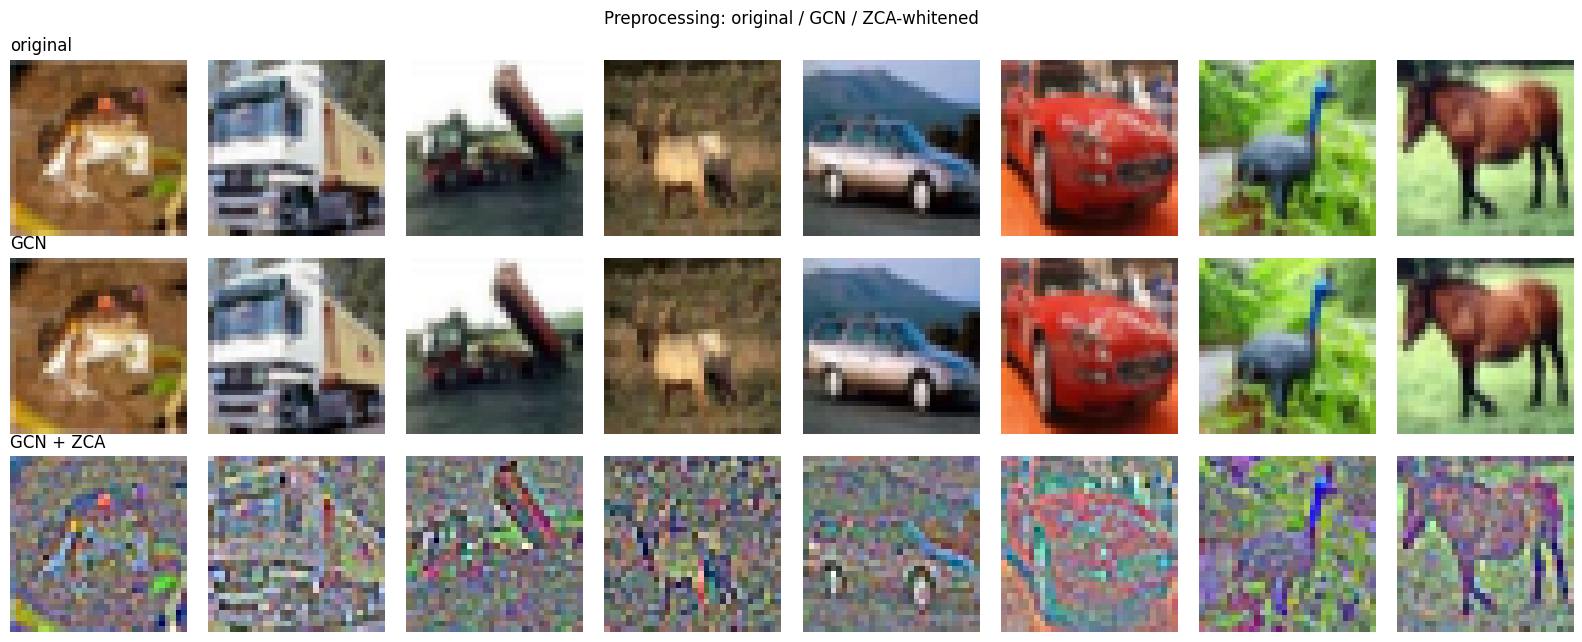

In [4]:
# ================= Visualize: original vs GCN vs ZCA =================
# Raw dataset (only ToTensor) just for the preprocessing demo
dataset_raw = datasets.CIFAR10('./data/cifar10', train=True, download=True,
                               transform=transforms.ToTensor())
class_names = dataset_raw.classes   # 10 class names

# Stack 1,000 images: (1000, 3, 32, 32) — enough for a meaningful covariance
demo_imgs = torch.stack([dataset_raw[i][0] for i in range(1000)])
print('demo batch:', demo_imgs.shape)

gcn_imgs = torch.stack([gcn(img) for img in demo_imgs])          # (1000, 3, 32, 32)
zca_imgs, ZCA_matrix, zca_mean = zca_whitening(gcn_imgs)         # (1000, 3, 32, 32)

n_show = 8
fig, axes = plt.subplots(3, n_show, figsize=(2 * n_show, 6.5))
for j in range(n_show):
    for i, (batch, title) in enumerate([(demo_imgs, 'original'),
                                        (gcn_imgs, 'GCN'),
                                        (zca_imgs, 'GCN + ZCA')]):
        # (C, H, W) -> (H, W, C) for matplotlib
        axes[i, j].imshow(deprocess(batch[j]).permute(1, 2, 0).numpy())
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(title, loc='left', fontsize=12)
plt.suptitle('Preprocessing: original / GCN / ZCA-whitened')
plt.tight_layout()
plt.show()


## 2. Custom layers

All layers are hand-rolled `nn.Module`s. Note that `super().__init__()` must be called **before** registering any `nn.Parameter`.

In [5]:
class BatchNorm(nn.Module):
    """y = gamma * x_normalized + beta

    `shape` is the per-feature-map shape, e.g. (C, H, W) = (32, 30, 30).
    gamma/beta of shape (C, H, W) broadcast against inputs of shape (N, C, H, W).
    NOTE: for simplicity this uses *batch statistics at eval time too*
    (a real BatchNorm keeps running averages).
    """
    def __init__(self, shape, epsilon=1e-5):
        super().__init__()                              # must come first!
        self.gamma = nn.Parameter(torch.ones(shape))    # (C, H, W)
        self.beta  = nn.Parameter(torch.zeros(shape))   # (C, H, W)
        self.epsilon = epsilon

    def forward(self, x):
        # x: (N, C, H, W). Reduce over batch(0), height(2), width(3), keep channel.
        x_mean = torch.mean(x, (0, 2, 3), keepdim=True)     # (1, C, 1, 1)
        x_var  = torch.var(x, (0, 2, 3), keepdim=True)      # (1, C, 1, 1)
        # (N, C, H, W) via broadcasting:
        x_normalized = (x - x_mean) / torch.sqrt(x_var + self.epsilon)
        return self.gamma * x_normalized + self.beta        # (N, C, H, W)


class Dropout(nn.Module):
    """Inverted dropout: scale by 1/(1-p) at train time, identity at eval time."""
    def __init__(self, dropout_ratio=0.5):
        super().__init__()
        self.dropout_ratio = dropout_ratio

    def forward(self, x):
        if self.training:
            mask = (torch.rand_like(x) > self.dropout_ratio).float()  # same shape as x
            return x * mask / (1.0 - self.dropout_ratio)
        return x


class Conv(nn.Module):
    """2D convolution with Glorot-uniform-scaled normal init.

    filter_shape = (out_channels, in_channels, kernel_H, kernel_W)
    """
    def __init__(self, filter_shape, function=lambda x: x, stride=(1, 1), padding=0):
        super().__init__()
        fan_in  = filter_shape[1] * filter_shape[2] * filter_shape[3]
        fan_out = filter_shape[0] * filter_shape[2] * filter_shape[3]
        self.W = nn.Parameter(torch.tensor(
            rng.normal(0, np.sqrt(6 / (fan_in + fan_out)), size=filter_shape),
            dtype=torch.float32))                       # (out_ch, in_ch, kH, kW)
        self.b = nn.Parameter(torch.zeros(filter_shape[0], dtype=torch.float32))  # (out_ch,)
        self.function = function
        self.stride = stride
        self.padding = padding

    def forward(self, x):
        # x: (N, in_ch, H, W) -> u: (N, out_ch, H', W')
        # H' = (H + 2*padding - kH) / stride + 1
        u = F.conv2d(x, self.W, self.b, self.stride, self.padding)
        return self.function(u)


class Pooling(nn.Module):
    """Average pooling. (N, C, H, W) -> (N, C, H//k, W//k)"""
    def __init__(self, kernel_size=(2, 2), stride=None, padding=0):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride if stride is not None else kernel_size
        self.padding = padding

    def forward(self, x):
        return F.avg_pool2d(x, kernel_size=self.kernel_size,
                            stride=self.stride, padding=self.padding)


class Flatten(nn.Module):
    """(N, C, H, W) -> (N, C*H*W)"""
    def forward(self, x):
        return x.view(x.size(0), -1)


class Dense(nn.Module):
    """Fully-connected layer, He-init. W: (in_dim, out_dim)"""
    def __init__(self, in_dim, out_dim, function=lambda x: x):
        super().__init__()
        self.W = nn.Parameter(torch.tensor(
            rng.normal(0, np.sqrt(2 / in_dim), size=(in_dim, out_dim)).astype(np.float32)))
        self.b = nn.Parameter(torch.zeros(out_dim, dtype=torch.float32))  # (out_dim,)
        self.function = function

    def forward(self, x):
        # (N, in_dim) @ (in_dim, out_dim) + (out_dim,) -> (N, out_dim)
        u = torch.matmul(x, self.W) + self.b
        return self.function(u)


class Activation(nn.Module):
    def __init__(self, function=lambda x: x):
        super().__init__()
        self.function = function

    def forward(self, x):
        return self.function(x)


## 3. Model

Shape flow for a `(N, 3, 32, 32)` input (no padding, so each 3×3 conv shrinks H/W by 2; each 2×2 avg-pool halves them, with floor):

| layer | output shape |
|---|---|
| input | (N, 3, 32, 32) |
| Conv 3→32, 3×3 | (N, 32, 30, 30) |
| Pool 2×2 | (N, 32, 15, 15) |
| Conv 32→64, 3×3 | (N, 64, 13, 13) |
| Pool 2×2 | (N, 64, 6, 6) |
| Conv 64→128, 3×3 | (N, 128, 4, 4) |
| Pool 2×2 | (N, 128, 2, 2) |
| Flatten | (N, 512) |
| Dense 512→10 | (N, 10) |

In [6]:
class CNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.conv_net = nn.Sequential(
            # ---- Block 1 ----
            Conv((32, 3, 3, 3)),      # (N, 3, 32, 32) -> (N, 32, 30, 30)
            BatchNorm((32, 30, 30)),
            Activation(F.relu),
            Pooling((2, 2)),          # (N, 32, 30, 30) -> (N, 32, 15, 15)
            # ---- Block 2 ----
            Conv((64, 32, 3, 3)),     # (N, 32, 15, 15) -> (N, 64, 13, 13)
            BatchNorm((64, 13, 13)),
            Activation(F.relu),
            Pooling((2, 2)),          # (N, 64, 13, 13) -> (N, 64, 6, 6)   (floor(13/2)=6)
            # ---- Block 3 ----
            Conv((128, 64, 3, 3)),    # (N, 64, 6, 6)  -> (N, 128, 4, 4)
            BatchNorm((128, 4, 4)),
            Activation(F.relu),
            Pooling((2, 2)),          # (N, 128, 4, 4) -> (N, 128, 2, 2)
            # ---- Classifier ----
            Flatten(),                # (N, 128, 2, 2) -> (N, 512)
            Dense(2 * 2 * 128, n_classes)   # (N, 512) -> (N, 10)  <- CIFAR-10 has 10 classes!
        )

    def forward(self, x):
        return self.conv_net(x)      # logits: (N, 10)


# --- Sanity check: trace the shape through every layer ---
model = CNN()
x = torch.zeros(2, 3, 32, 32)        # dummy batch of 2
print(f"{'input':>12s} -> {tuple(x.shape)}")
for layer in model.conv_net:
    x = layer(x)
    print(f'{layer.__class__.__name__:>12s} -> {tuple(x.shape)}')

n_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {n_params:,}')


       input -> (2, 3, 32, 32)
        Conv -> (2, 32, 30, 30)
   BatchNorm -> (2, 32, 30, 30)
  Activation -> (2, 32, 30, 30)
     Pooling -> (2, 32, 15, 15)
        Conv -> (2, 64, 13, 13)
   BatchNorm -> (2, 64, 13, 13)
  Activation -> (2, 64, 13, 13)
     Pooling -> (2, 64, 6, 6)
        Conv -> (2, 128, 4, 4)
   BatchNorm -> (2, 128, 4, 4)
  Activation -> (2, 128, 4, 4)
     Pooling -> (2, 128, 2, 2)
     Flatten -> (2, 512)
       Dense -> (2, 10)

Total parameters: 181,706


## 4. Data loaders and training

The original code trained on **only the first batch** (via `next(iter(loader))`) — here we train properly on the full 50k training images with mini-batches, and validate on the 10k test images. GCN is applied per-image inside the transform pipeline.

In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),           # PIL -> (C, H, W) float tensor in [0, 1]
    transforms.Lambda(gcn),          # per-image GCN: (3, 32, 32) -> (3, 32, 32)
])

dataloader_train = DataLoader(
    datasets.CIFAR10('./data/cifar10', train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True,  num_workers=2)
dataloader_val = DataLoader(
    datasets.CIFAR10('./data/cifar10', train=False, download=True, transform=transform),
    batch_size=batch_size, shuffle=False, num_workers=2)

print(f'train batches: {len(dataloader_train)}, val batches: {len(dataloader_val)}')


train batches: 782, val batches: 157


In [8]:
def evaluate(model, loader):
    """Returns (mean loss, accuracy) over a loader."""
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for x, t in loader:
            x, t = x.to(device), t.to(device)   # x: (B, 3, 32, 32), t: (B,)
            y = model(x)                        # logits: (B, 10)
            total_loss += F.cross_entropy(y, t, reduction='sum').item()
            correct += (y.argmax(dim=1) == t).sum().item()
            n += t.size(0)
    return total_loss / n, correct / n


n_epochs = 5
lr = 1e-3

model = CNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

losses_train, losses_val = [], []
accs_train, accs_val = [], []

for epoch in range(n_epochs):
    model.train()
    running_loss, correct, n = 0.0, 0, 0
    for x, t in tqdm(dataloader_train, desc=f'epoch {epoch+1}/{n_epochs}', leave=False):
        x, t = x.to(device), t.to(device)   # x: (B, 3, 32, 32), t: (B,)
        y = model(x)                        # logits: (B, 10)
        loss = F.cross_entropy(y, t)        # scalar
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * t.size(0)
        correct += (y.argmax(dim=1) == t).sum().item()
        n += t.size(0)

    train_loss, train_acc = running_loss / n, correct / n
    val_loss, val_acc = evaluate(model, dataloader_val)

    losses_train.append(train_loss); accs_train.append(train_acc)
    losses_val.append(val_loss);     accs_val.append(val_acc)
    print(f'epoch {epoch+1:2d} | train loss {train_loss:.4f} acc {train_acc:.4f} '
          f'| val loss {val_loss:.4f} acc {val_acc:.4f}')


epoch 1/5:   0%|          | 0/782 [00:00<?, ?it/s]

epoch  1 | train loss 1.2830 acc 0.5462 | val loss 1.0603 acc 0.6298


epoch 2/5:   0%|          | 0/782 [00:00<?, ?it/s]

epoch  2 | train loss 0.9496 acc 0.6692 | val loss 0.9499 acc 0.6664


epoch 3/5:   0%|          | 0/782 [00:00<?, ?it/s]

epoch  3 | train loss 0.8068 acc 0.7201 | val loss 0.8352 acc 0.7037


epoch 4/5:   0%|          | 0/782 [00:00<?, ?it/s]

epoch  4 | train loss 0.7197 acc 0.7500 | val loss 0.7815 acc 0.7305


epoch 5/5:   0%|          | 0/782 [00:00<?, ?it/s]

epoch  5 | train loss 0.6461 acc 0.7776 | val loss 0.7511 acc 0.7407


## 5. Results

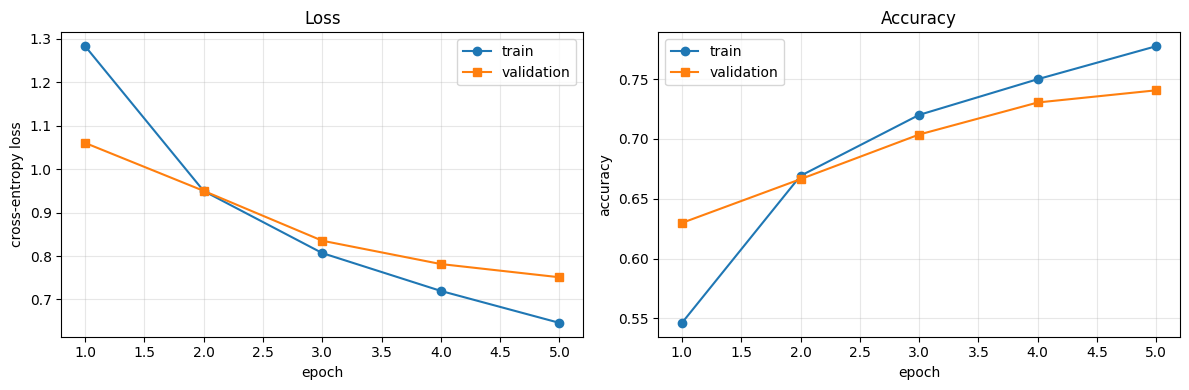

In [9]:
# ================= Learning curves =================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, n_epochs + 1)

ax1.plot(epochs, losses_train, 'o-', label='train')
ax1.plot(epochs, losses_val, 's-', label='validation')
ax1.set_xlabel('epoch'); ax1.set_ylabel('cross-entropy loss')
ax1.set_title('Loss'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs, accs_train, 'o-', label='train')
ax2.plot(epochs, accs_val, 's-', label='validation')
ax2.set_xlabel('epoch'); ax2.set_ylabel('accuracy')
ax2.set_title('Accuracy'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Validation accuracy: 0.7407
Macro F1 score:      0.7398


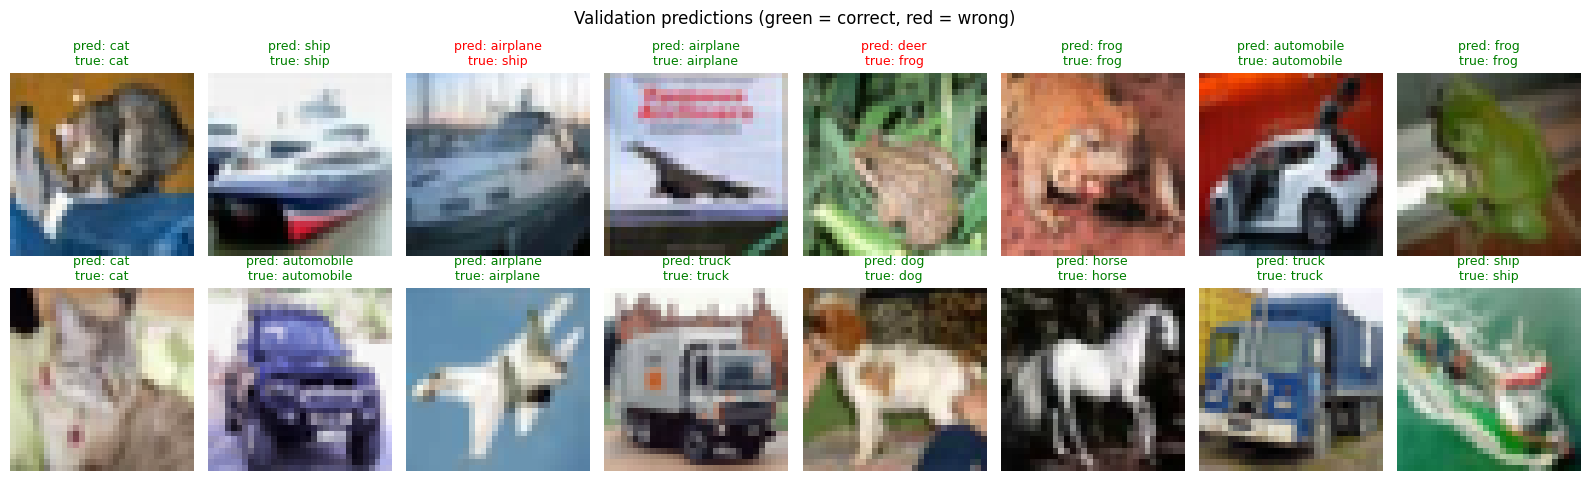

In [10]:
# ================= Final metrics & sample predictions =================
model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for x, t in dataloader_val:
        y = model(x.to(device))                       # (B, 10)
        all_preds.append(y.argmax(dim=1).cpu())       # (B,)
        all_targets.append(t)
all_preds = torch.cat(all_preds).numpy()              # (10000,)
all_targets = torch.cat(all_targets).numpy()          # (10000,)

print(f'Validation accuracy: {accuracy_score(all_targets, all_preds):.4f}')
print(f'Macro F1 score:      {f1_score(all_targets, all_preds, average="macro"):.4f}')

# Show 16 validation images with predicted / true labels
x_show, t_show = next(iter(dataloader_val))           # (64, 3, 32, 32), (64,)
with torch.no_grad():
    p_show = model(x_show.to(device)).argmax(dim=1).cpu()  # (64,)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for k, ax in enumerate(axes.flat):
    ax.imshow(deprocess(x_show[k]).permute(1, 2, 0).numpy())  # (H, W, C)
    ok = p_show[k] == t_show[k]
    ax.set_title(f'pred: {class_names[p_show[k]]}\ntrue: {class_names[t_show[k]]}',
                 fontsize=9, color=('green' if ok else 'red'))
    ax.axis('off')
plt.suptitle('Validation predictions (green = correct, red = wrong)')
plt.tight_layout()
plt.show()
